<a href="https://colab.research.google.com/github/habibiputrar/BigData26_A_2411531001_Habibi-Putra-Rizqullah-/blob/main/Praktikum03/BD_A_TugasP03_2411531001_Habibi_Putra_Rizqullah_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS PRAKTIKUM BIG DATA - PRAKTIKUM 3
## Pipeline Dua Bulan dan Pra-pemrosesan Data yang Dapat Ditelusuri

Bulan yang dibandingkan adalah **Januari 2023** dan **Juli 2023**.

Sumber data yang digunakan:

1. NYC TLC Yellow Taxi Trip Records.
2. NYC TLC Taxi Zone Lookup.
3. Open-Meteo Historical Weather API.
4. Nager.Date Public Holidays API sebagai sumber keempat.


# R. Tugas Praktikum

## R.0 Persiapan Lingkungan

Sel ini memeriksa pustaka, menghubungkan Google Drive, menentukan periode, dan membuat struktur folder. Pustaka hanya dipasang apabila belum tersedia agar versi yang sudah ada tidak berubah tanpa alasan.

In [1]:
import importlib.util
import subprocess
import sys

pustaka = {
    "pandas": "pandas",
    "numpy": "numpy",
    "pyarrow": "pyarrow",
    "requests": "requests",
    "matplotlib": "matplotlib",
    "psutil": "psutil",
}

belum_terpasang = [
    paket for modul, paket in pustaka.items()
    if importlib.util.find_spec(modul) is None
]

if belum_terpasang:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        *belum_terpasang
    ])

import gc
import hashlib
import json
import os
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyarrow
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import requests
from IPython.display import Image, display

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_CONTENT = Path("/content")
    BASE_DRIVE = Path("/content/drive/MyDrive")
except ImportError:
    # Jalur ini hanya dipakai ketika notebook diuji di luar Colab.
    BASE_CONTENT = Path.cwd() / "content"
    BASE_DRIVE = Path.cwd() / "drive"

PERIODE = ["2023-01", "2023-07"]

DIR_MENTAH = BASE_CONTENT / "lapisan_mentah_tugas_p03"
DIR_KURASI = BASE_CONTENT / "lapisan_terkurasi_tugas_p03"
DIR_SIMPAN = BASE_DRIVE / "BigData" / "Praktikum3" / "TugasPraktikum3"
DIR_OUTPUT = DIR_SIMPAN / "trips_bersih"
DIR_ARTEFAK = DIR_SIMPAN / "artefak"

for direktori in (
    DIR_MENTAH, DIR_KURASI, DIR_SIMPAN,
    DIR_OUTPUT, DIR_ARTEFAK
):
    direktori.mkdir(parents=True, exist_ok=True)

print("Python   :", sys.version.split()[0])
print("pandas   :", pd.__version__)
print("NumPy    :", np.__version__)
print("PyArrow  :", pyarrow.__version__)
print("requests :", requests.__version__)
print("Periode  :", PERIODE)
print("Output   :", DIR_SIMPAN)

Mounted at /content/drive
Python   : 3.13.15
pandas   : 2.2.3
NumPy    : 2.1.3
PyArrow  : 23.0.1
requests : 2.32.4
Periode  : ['2023-01', '2023-07']
Output   : /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3


**Penjelasan kode.** `Path` dipakai supaya pengelolaan alamat folder lebih aman dan mudah dibaca. Folder mentah dan kurasi berada di penyimpanan sementara Colab, sedangkan artefak akhir disimpan di Google Drive. Daftar `PERIODE` menjadi satu-satunya tempat untuk mengubah bulan yang diproses.

## R.1 Fungsi Umum, Cache, dan Pencatatan

Unduhan dilakukan ke berkas sementara `.part`, kemudian dipindahkan secara atomik setelah selesai. Cache tidak hanya diperiksa berdasarkan keberadaan berkas, tetapi juga berdasarkan kemampuan berkas untuk dibaca.

In [2]:
proses = psutil.Process(os.getpid())
catatan_kinerja = []
lineage_records = []


def rss_mb():
    return proses.memory_info().rss / 1024**2


def ukur(label, fungsi):
    memori_awal = rss_mb()
    waktu_awal = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - waktu_awal
    delta_memori = rss_mb() - memori_awal

    catatan_kinerja.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta_memori, 1),
    })
    print(
        f"[{label}] {detik:.2f} detik | "
        f"delta RSS: {delta_memori:.1f} MB"
    )
    return hasil


def catat_lineage(sumber, periode, asal, jumlah_baris, keterangan):
    lineage_records.append({
        "sumber": sumber,
        "periode": periode,
        "asal": asal,
        "diambil_pada_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "jumlah_baris": int(jumlah_baris),
        "keterangan": keterangan,
    })


def sha256_file(path, ukuran_blok=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as berkas:
        while blok := berkas.read(ukuran_blok):
            digest.update(blok)
    return digest.hexdigest()


def cache_valid(path, jenis):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return False

    try:
        if jenis == "parquet":
            pq.ParquetFile(path)
        elif jenis == "csv":
            pd.read_csv(path, nrows=3)
        elif jenis == "json":
            with open(path, encoding="utf-8") as berkas:
                json.load(berkas)
        else:
            raise ValueError(f"Jenis berkas tidak didukung: {jenis}")
        return True
    except Exception:
        return False


def unduh_aman(url, tujuan, jenis, percobaan=3, jeda_awal=2):
    tujuan = Path(tujuan)
    tujuan.parent.mkdir(parents=True, exist_ok=True)

    if cache_valid(tujuan, jenis):
        print(f"Cache ditemukan: {tujuan.name}")
        return tujuan

    sementara = tujuan.with_suffix(tujuan.suffix + ".part")
    if sementara.exists():
        sementara.unlink()

    for indeks in range(percobaan):
        try:
            waktu_awal = time.perf_counter()
            jumlah_byte = 0

            with requests.get(url, stream=True, timeout=120) as respons:
                if respons.status_code in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(
                        f"Status sementara {respons.status_code}"
                    )
                respons.raise_for_status()

                with open(sementara, "wb") as berkas:
                    for blok in respons.iter_content(chunk_size=1024 * 1024):
                        if blok:
                            berkas.write(blok)
                            jumlah_byte += len(blok)

            if not cache_valid(sementara, jenis):
                raise ValueError("Berkas hasil unduhan tidak valid")

            os.replace(sementara, tujuan)
            detik = max(time.perf_counter() - waktu_awal, 1e-9)
            kecepatan = jumlah_byte / 1024**2 / detik
            print(
                f"Unduhan selesai: {tujuan.name} | "
                f"{kecepatan:.2f} MB/detik"
            )
            return tujuan

        except Exception as error:
            if sementara.exists():
                sementara.unlink()
            if indeks == percobaan - 1:
                raise
            tunggu = jeda_awal * (2 ** indeks)
            print(f"Percobaan gagal: {error}. Ulang {tunggu} detik.")
            time.sleep(tunggu)

    raise RuntimeError("Unduhan tidak berhasil")

**Penjelasan kode.** `ukur()` menyimpan waktu dan perubahan RSS untuk setiap proses yang diukur. `cache_valid()` mencegah berkas rusak dianggap sebagai cache. `os.replace()` dipakai agar nama berkas akhir hanya muncul setelah unduhan selesai. Fungsi `sha256_file()` membantu membuktikan bahwa sumber yang dipakai dapat ditelusuri sampai ke berkas mentahnya.

## R.2 Akuisisi Tabel Referensi dan Sumber Keempat

Sumber keempat yang dipilih adalah kalender hari libur nasional Amerika Serikat dari **Nager.Date Public Holidays API**. Data ini diintegrasikan berdasarkan tanggal penjemputan. Endpoint v3 dipakai karena masih menyediakan data historis tahun 2023; endpoint komunitas v4 saat ini tidak menerima tahun tersebut.

Dokumentasi sumber: [Nager Holidays API](https://nagerholidays.com/api) dan [ketentuan penggunaan](https://nagerholidays.com/terms).

In [3]:
URL_ZONA = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "misc/taxi_zone_lookup.csv"
)
PATH_ZONA = DIR_MENTAH / "taxi_zone_lookup.csv"

unduh_aman(URL_ZONA, PATH_ZONA, "csv")

# keep_default_na=False mempertahankan teks literal seperti "N/A".
zona = pd.read_csv(PATH_ZONA, keep_default_na=False)

if not zona["LocationID"].is_unique:
    raise ValueError("LocationID pada tabel zona tidak unik")

referensi_pembayaran = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": [
        "Kartu kredit", "Tunai", "Gratis",
        "Sengketa", "Tidak diketahui", "Perjalanan batal"
    ],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})

URL_LIBUR = (
    "https://date.nager.at/api/v3/"
    "PublicHolidays/2023/US"
)
PATH_LIBUR = DIR_MENTAH / "hari_libur_us_2023.json"

unduh_aman(URL_LIBUR, PATH_LIBUR, "json")

with open(PATH_LIBUR, encoding="utf-8") as berkas:
    libur_raw = json.load(berkas)

libur = pd.DataFrame(libur_raw)
kolom_wajib_libur = {"date", "name", "global"}
if not kolom_wajib_libur.issubset(libur.columns):
    raise ValueError("Struktur respons API hari libur berubah")

libur = (
    libur.loc[libur["global"].fillna(False), ["date", "name"]]
    .assign(tanggal=lambda d: pd.to_datetime(d["date"]))
    .groupby("tanggal", as_index=False)
    .agg(nama_libur=("name", lambda s: " / ".join(dict.fromkeys(s))))
)
libur["libur_nasional"] = np.int8(1)

catat_lineage(
    "taxi_zone_lookup", "referensi", URL_ZONA,
    len(zona), "Tabel referensi zona NYC TLC"
)
catat_lineage(
    "hari_libur_us", "2023", URL_LIBUR,
    len(libur), "Sumber keempat; hari libur nasional AS"
)

print("Tabel zona      :", zona.shape)
print("Hari libur 2023 :", libur.shape)
display(libur.head())

Unduhan selesai: taxi_zone_lookup.csv | 0.10 MB/detik
Unduhan selesai: hari_libur_us_2023.json | 0.04 MB/detik
Tabel zona      : (265, 4)
Hari libur 2023 : (11, 3)


,tanggal,nama_libur,libur_nasional
0,2023-01-02,New Year's Day,1
1,2023-01-16,"Martin Luther King, Jr. Day",1
2,2023-02-20,Presidents Day,1
3,2023-05-29,Memorial Day,1
4,2023-06-19,Juneteenth National Independence Day,1


**Penjelasan kode.** Tabel zona dibaca dengan `keep_default_na=False` agar nama zona yang tertulis `N/A` tidak otomatis berubah menjadi nilai kosong. Data hari libur disaring ke hari libur berskala nasional, lalu diringkas menjadi satu baris per tanggal supaya aman digunakan dalam join `many_to_one`.

## R.3 Fungsi Akuisisi Cuaca dan Laporan Kualitas

Data cuaca diambil per bulan dari Open-Meteo dengan zona waktu `America/New_York`. Delapan aturan kualitas dibuat sama untuk kedua bulan agar hasilnya dapat dibandingkan secara adil.

In [4]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"


def simpan_json_atomik(data, tujuan):
    tujuan = Path(tujuan)
    sementara = tujuan.with_suffix(tujuan.suffix + ".part")
    with open(sementara, "w", encoding="utf-8") as berkas:
        json.dump(data, berkas, ensure_ascii=False)
    os.replace(sementara, tujuan)


def ambil_cuaca(bulan, percobaan=3):
    periode = pd.Period(bulan, freq="M")
    tanggal_awal = periode.start_time.strftime("%Y-%m-%d")
    tanggal_akhir = periode.end_time.strftime("%Y-%m-%d")
    path_cache = DIR_MENTAH / f"cuaca_{bulan}.json"

    if cache_valid(path_cache, "json"):
        with open(path_cache, encoding="utf-8") as berkas:
            data = json.load(berkas)
        print(f"Cache cuaca ditemukan: {path_cache.name}")
    else:
        params = {
            "latitude": 40.7128,
            "longitude": -74.0060,
            "start_date": tanggal_awal,
            "end_date": tanggal_akhir,
            "hourly": "temperature_2m,precipitation",
            "timezone": "America/New_York",
        }

        for indeks in range(percobaan):
            try:
                respons = requests.get(
                    API_CUACA, params=params, timeout=120
                )
                if respons.status_code in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(
                        f"Status sementara {respons.status_code}"
                    )
                respons.raise_for_status()
                data = respons.json()
                if "hourly" not in data:
                    raise ValueError("Bagian hourly tidak ditemukan")
                simpan_json_atomik(data, path_cache)
                break
            except Exception:
                if indeks == percobaan - 1:
                    raise
                time.sleep(2 ** (indeks + 1))

    hourly = data.get("hourly", {})
    kolom_wajib = {"time", "temperature_2m", "precipitation"}
    if not kolom_wajib.issubset(hourly):
        raise ValueError("Kolom cuaca wajib tidak lengkap")

    cuaca = pd.DataFrame({
        "jam_mulai": pd.to_datetime(hourly["time"]),
        "suhu_c": pd.to_numeric(
            hourly["temperature_2m"], errors="coerce"
        ),
        "hujan_mm": pd.to_numeric(
            hourly["precipitation"], errors="coerce"
        ),
    })

    if not cuaca["jam_mulai"].is_unique:
        raise ValueError("Kunci jam pada data cuaca tidak unik")

    catat_lineage(
        "open_meteo", bulan, API_CUACA, len(cuaca),
        "Suhu dan presipitasi per jam di New York City"
    )
    return cuaca


def buat_laporan_kualitas(trip, bulan, zona_ref):
    periode = pd.Period(bulan, freq="M")
    awal = periode.start_time
    akhir = (periode + 1).start_time

    aturan = {
        "kelengkapan: passenger_count ada": (
            trip["passenger_count"].notna()
        ),
        "validitas: jarak 0,01-100 mil": (
            trip["trip_distance"].between(0.01, 100)
        ),
        "konsistensi: durasi 1-180 menit": (
            trip["durasi_menit"].between(1, 180)
        ),
        "validitas: total_amount > 0": (
            trip["total_amount"] > 0
        ),
        "konsistensi: total >= fare": (
            trip["total_amount"] >= trip["fare_amount"]
        ),
        "ketepatan waktu: dalam periode berkas": (
            trip["tpep_pickup_datetime"].ge(awal)
            & trip["tpep_pickup_datetime"].lt(akhir)
        ),
        "keunikan: baris tidak duplikat": (
            ~trip.duplicated()
        ),
        "validitas: PULocationID dikenal": (
            trip["PULocationID"].isin(zona_ref["LocationID"])
        ),
    }

    hasil = []
    for nama, mask in aturan.items():
        mask = mask.fillna(False)
        lulus = int(mask.sum())
        gagal = int((~mask).sum())
        hasil.append({
            "periode": bulan,
            "aturan": nama,
            "lulus": lulus,
            "gagal": gagal,
            "persen_gagal": round(gagal / len(trip) * 100, 4),
        })

    return pd.DataFrame(hasil).sort_values(
        "persen_gagal", ascending=False
    ).reset_index(drop=True)

**Penjelasan kode.** Respons cuaca mentah disimpan sebagai JSON agar akuisisinya dapat diaudit. Laporan kualitas menghitung jumlah lulus, gagal, dan persentase gagal dari mask Boolean yang sama pada setiap bulan. Batas jarak dan durasi adalah keputusan analitis dari praktikum, bukan aturan mutlak bahwa seluruh nilai di luar batas pasti salah.

## R.4 Pipeline Dua Bulan

Pipeline memproses satu bulan dalam satu waktu agar penggunaan memori tidak menumpuk. Setiap bulan ditulis ke direktori `periode=YYYY-MM` yang sama, lalu dipartisi lagi menurut `borough_naik`. Baris di luar periode diminta dibuang sebelum penyimpanan sehingga catatan dari dua bulan tidak saling tumpang tindih.

In [5]:
KOLOM_TRIP = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
]

KUNCI_PERJALANAN = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount",
]

KOLOM_AKHIR = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "passenger_count_diimputasi",
    "trip_distance",
    "trip_distance_capped",
    "durasi_menit",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "tarif_ekstrem",
    "zona_naik",
    "borough_naik",
    "service_zone",
    "nama_pembayaran",
    "kena_biaya_admin",
    "jam_mulai",
    "suhu_c",
    "hujan_mm",
    "cuaca_tersedia",
    "hujan",
    "tanggal",
    "nama_libur",
    "libur_nasional",
    "hari_minggu",
    "akhir_pekan",
    "kecepatan_mph",
    "tarif_per_mil",
    "periode",
]


def validasi_hasil(data, bulan):
    hilang = sorted(set(KOLOM_AKHIR) - set(data.columns))
    if hilang:
        raise AssertionError(f"Kolom akhir belum lengkap: {hilang}")
    if data.empty:
        raise AssertionError("Dataset akhir kosong")
    if data.duplicated(KUNCI_PERJALANAN).any():
        raise AssertionError("Masih ada duplikat kunci perjalanan")
    if not data["periode"].eq(bulan).all():
        raise AssertionError("Label periode tidak konsisten")

    awal = pd.Period(bulan, freq="M").start_time
    akhir = (pd.Period(bulan, freq="M") + 1).start_time
    if not data["tpep_pickup_datetime"].between(
        awal, akhir, inclusive="left"
    ).all():
        raise AssertionError("Ada waktu pickup di luar periode")


def pipeline_bulan(bulan):
    dir_final = DIR_OUTPUT / f"periode={bulan}"
    path_sukses = dir_final / "_SUCCESS.json"

    # Idempotensi: keluaran lengkap tidak ditulis ulang.
    if path_sukses.exists():
        with open(path_sukses, encoding="utf-8") as berkas:
            metadata = json.load(berkas)
        metadata["status"] = "cache"
        for item in metadata.get("lineage", []):
            lineage_records.append(item)
        print(f"[{bulan}] cache keluaran ditemukan; proses dilewati")
        return metadata

    url_trip = (
        "https://d37ci6vzurychx.cloudfront.net/trip-data/"
        f"yellow_tripdata_{bulan}.parquet"
    )
    path_trip = DIR_MENTAH / f"yellow_tripdata_{bulan}.parquet"
    unduh_aman(url_trip, path_trip, "parquet")

    waktu_pipeline = time.perf_counter()
    rss_awal_pipeline = rss_mb()

    trip = ukur(
        f"{bulan}: baca parquet",
        lambda: pd.read_parquet(path_trip, columns=KOLOM_TRIP)
    )
    jumlah_awal = len(trip)

    trip["durasi_menit"] = (
        (
            trip["tpep_dropoff_datetime"]
            - trip["tpep_pickup_datetime"]
        ).dt.total_seconds() / 60
    )

    laporan = buat_laporan_kualitas(trip, bulan, zona)
    path_laporan = DIR_ARTEFAK / f"laporan_kualitas_{bulan}.csv"
    laporan.to_csv(path_laporan, index=False)

    periode = pd.Period(bulan, freq="M")
    awal = periode.start_time
    akhir = (periode + 1).start_time
    trip = trip.loc[
        trip["tpep_pickup_datetime"].ge(awal)
        & trip["tpep_pickup_datetime"].lt(akhir)
    ].copy()
    jumlah_dalam_periode = len(trip)

    trip["passenger_count_diimputasi"] = (
        trip["passenger_count"].isna().astype("int8")
    )
    jam_pickup = trip["tpep_pickup_datetime"].dt.hour
    median_per_jam = trip.groupby(
        jam_pickup, observed=True
    )["passenger_count"].transform("median")
    median_global = trip["passenger_count"].median()
    trip["passenger_count"] = (
        trip["passenger_count"]
        .fillna(median_per_jam)
        .fillna(median_global)
    )

    sebelum_duplikat = len(trip)
    trip = trip.drop_duplicates(
        subset=KUNCI_PERJALANAN, keep="first"
    ).copy()
    dibuang_duplikat = sebelum_duplikat - len(trip)

    mask_valid = (
        trip["trip_distance"].between(0.01, 100)
        & trip["durasi_menit"].between(1, 180)
        & trip["total_amount"].gt(0)
    )
    sebelum_filter = len(trip)
    trip = trip.loc[mask_valid].copy()
    dibuang_filter = sebelum_filter - len(trip)

    q1 = trip["total_amount"].quantile(0.25)
    q3 = trip["total_amount"].quantile(0.75)
    batas_tarif = q3 + 1.5 * (q3 - q1)
    trip["tarif_ekstrem"] = (
        trip["total_amount"] > batas_tarif
    ).astype("int8")

    batas_jarak = trip["trip_distance"].quantile(0.995)
    trip["trip_distance_capped"] = trip["trip_distance"].clip(
        upper=batas_jarak
    )

    zona_join = zona[[
        "LocationID", "Borough", "Zone", "service_zone"
    ]].rename(columns={
        "Borough": "borough_naik",
        "Zone": "zona_naik",
    })

    trip = trip.merge(
        zona_join,
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one",
    ).drop(columns="LocationID")

    trip["borough_naik"] = (
        trip["borough_naik"].replace("", np.nan)
        .fillna("Unknown")
    )
    trip["zona_naik"] = (
        trip["zona_naik"].replace("", np.nan)
        .fillna("Tidak diketahui")
    )
    trip["service_zone"] = (
        trip["service_zone"].replace("", np.nan)
        .fillna("Tidak diketahui")
    )

    trip = trip.merge(
        referensi_pembayaran,
        on="payment_type",
        how="left",
        validate="many_to_one",
    )
    trip["nama_pembayaran"] = trip[
        "nama_pembayaran"
    ].fillna("Tidak diketahui")
    trip["kena_biaya_admin"] = trip[
        "kena_biaya_admin"
    ].fillna(0).astype("int8")

    cuaca = ambil_cuaca(bulan)
    trip["jam_mulai"] = trip[
        "tpep_pickup_datetime"
    ].dt.floor("h")
    trip = trip.merge(
        cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one",
    )

    trip["tanggal"] = trip[
        "tpep_pickup_datetime"
    ].dt.normalize()
    trip = trip.merge(
        libur,
        on="tanggal",
        how="left",
        validate="many_to_one",
    )
    trip["nama_libur"] = trip[
        "nama_libur"
    ].fillna("Bukan hari libur")
    trip["libur_nasional"] = trip[
        "libur_nasional"
    ].fillna(0).astype("int8")

    trip["cuaca_tersedia"] = (
        trip["suhu_c"].notna() & trip["hujan_mm"].notna()
    )
    trip["hujan"] = (
        trip["hujan_mm"].gt(0.1).astype("Int8")
    )
    trip.loc[~trip["cuaca_tersedia"], "hujan"] = pd.NA

    trip["hari_minggu"] = trip[
        "tpep_pickup_datetime"
    ].dt.dayofweek.astype("int8")
    trip["akhir_pekan"] = (
        trip["hari_minggu"] >= 5
    ).astype("int8")
    trip["kecepatan_mph"] = (
        trip["trip_distance"]
        / (trip["durasi_menit"] / 60)
    ).round(2)
    trip["tarif_per_mil"] = (
        trip["total_amount"] / trip["trip_distance"]
    ).round(3)
    trip["periode"] = bulan

    hasil = trip[KOLOM_AKHIR].copy()
    validasi_hasil(hasil, bulan)

    dir_sementara = DIR_OUTPUT / f".periode={bulan}.tmp"
    if dir_sementara.exists():
        shutil.rmtree(dir_sementara)
    if dir_final.exists():
        # Direktori tanpa _SUCCESS dianggap hasil tidak lengkap.
        shutil.rmtree(dir_final)

    hasil.to_parquet(
        dir_sementara,
        index=False,
        compression="snappy",
        partition_cols=["borough_naik"],
    )

    lineage_bulan = [
        {
            "sumber": "nyc_tlc_trip",
            "periode": bulan,
            "asal": url_trip,
            "diambil_pada_utc": pd.Timestamp.now(
                tz="UTC"
            ).isoformat(),
            "jumlah_baris": int(jumlah_awal),
            "keterangan": (
                "Data perjalanan mentah; sha256="
                + sha256_file(path_trip)
            ),
        },
        {
            "sumber": "dataset_bersih",
            "periode": bulan,
            "asal": str(path_trip),
            "diambil_pada_utc": pd.Timestamp.now(
                tz="UTC"
            ).isoformat(),
            "jumlah_baris": int(len(hasil)),
            "keterangan": (
                "Setelah filter periode, imputasi, deduplikasi, "
                "filter validitas, dan empat join"
            ),
        },
    ]
    lineage_records.extend(lineage_bulan)

    metadata = {
        "periode": bulan,
        "status": "dibuat",
        "baris_awal": int(jumlah_awal),
        "baris_dalam_periode": int(jumlah_dalam_periode),
        "baris_akhir": int(len(hasil)),
        "dibuang_luar_periode": int(
            jumlah_awal - jumlah_dalam_periode
        ),
        "dibuang_duplikat": int(dibuang_duplikat),
        "dibuang_filter": int(dibuang_filter),
        "cuaca_tidak_tersedia": int(
            (~hasil["cuaca_tersedia"]).sum()
        ),
        "baris_hari_libur": int(
            hasil["libur_nasional"].sum()
        ),
        "waktu_pipeline_detik": round(
            time.perf_counter() - waktu_pipeline, 2
        ),
        "delta_rss_mb": round(rss_mb() - rss_awal_pipeline, 1),
        "laporan_kualitas": str(path_laporan),
        "lineage": lineage_bulan,
    }

    with open(
        dir_sementara / "_SUCCESS.json",
        "w",
        encoding="utf-8",
    ) as berkas:
        json.dump(metadata, berkas, indent=2, ensure_ascii=False)

    os.replace(dir_sementara, dir_final)
    print(
        f"[{bulan}] {jumlah_awal:,} -> {len(hasil):,} baris | "
        f"tersimpan di {dir_final}"
    )

    del trip, hasil, cuaca, laporan
    gc.collect()
    return metadata

**Penjelasan kode.** `pipeline_bulan()` memeriksa penanda keberhasilan sebelum melakukan pekerjaan. Jika belum ada, data dibaca, dinilai kualitasnya, dibersihkan, digabungkan dengan empat sumber, divalidasi, lalu ditulis melalui direktori sementara. Partisi `periode` mencegah hasil Januari tertimpa ketika Juli ditambahkan, sedangkan partisi borough memudahkan pembacaan terarah.

## R.5 Menjalankan Pipeline Januari dan Juli 2023

Kedua bulan diproses secara berurutan. Tabel ringkasan berikut berasal dari metadata aktual setiap proses.

In [6]:
metadata_bulan = {}

for bulan in PERIODE:
    metadata_bulan[bulan] = pipeline_bulan(bulan)
    gc.collect()

ringkasan_pipeline = pd.DataFrame([
    {
        "periode": bulan,
        "status": meta["status"],
        "baris_awal": meta["baris_awal"],
        "baris_akhir": meta["baris_akhir"],
        "persen_tersisa": round(
            meta["baris_akhir"] / meta["baris_awal"] * 100, 4
        ),
        "dibuang_luar_periode": meta["dibuang_luar_periode"],
        "dibuang_duplikat": meta["dibuang_duplikat"],
        "dibuang_filter": meta["dibuang_filter"],
        "waktu_pipeline_detik": meta["waktu_pipeline_detik"],
        "delta_rss_mb": meta["delta_rss_mb"],
    }
    for bulan, meta in metadata_bulan.items()
])

display(ringkasan_pipeline)

[2023-01] cache keluaran ditemukan; proses dilewati
[2023-07] cache keluaran ditemukan; proses dilewati


,periode,status,baris_awal,baris_akhir,persen_tersisa,dibuang_luar_periode,dibuang_duplikat,dibuang_filter,waktu_pipeline_detik,delta_rss_mb
0,2023-01,cache,3066766,2986873,97.3949,48,1,79844,25.33,2565.5
1,2023-07,cache,2907108,2817607,96.9213,59,0,89442,20.48,1583.4


**Pembahasan.** Gunakan angka yang muncul pada tabel untuk membahas perbedaan jumlah data awal, persentase yang bertahan, waktu proses, dan perubahan memori. Hindari menyimpulkan bahwa satu bulan lebih bermasalah hanya dari jumlah gagal absolut; persentase perlu dibandingkan karena jumlah baris kedua bulan dapat berbeda.

## R.6 Membuktikan Tidak Ada Duplikasi Antar-bulan

Bukti dilakukan dengan membaca kolom kunci saja. Hash kunci Januari dan Juli dibandingkan untuk menemukan kemungkinan catatan yang sama pada dua partisi.

In [7]:
hash_periode = {}
ringkasan_duplikat = []

for bulan in PERIODE:
    path_bulan = DIR_OUTPUT / f"periode={bulan}"
    kunci = pd.read_parquet(
        path_bulan,
        columns=KUNCI_PERJALANAN,
    )
    duplikat_dalam = int(
        kunci.duplicated(KUNCI_PERJALANAN).sum()
    )
    hash_periode[bulan] = np.unique(
        pd.util.hash_pandas_object(
            kunci[KUNCI_PERJALANAN], index=False
        ).to_numpy()
    )
    ringkasan_duplikat.append({
        "periode": bulan,
        "jumlah_baris": len(kunci),
        "duplikat_dalam_bulan": duplikat_dalam,
    })
    del kunci
    gc.collect()

duplikat_antar_bulan = int(np.intersect1d(
    hash_periode[PERIODE[0]],
    hash_periode[PERIODE[1]],
    assume_unique=True,
).size)

tabel_duplikat = pd.DataFrame(ringkasan_duplikat)
display(tabel_duplikat)
print("Duplikat antar-bulan:", duplikat_antar_bulan)

assert tabel_duplikat["duplikat_dalam_bulan"].sum() == 0
assert duplikat_antar_bulan == 0
print("Validasi lulus: tidak ada duplikasi dalam atau antar-bulan.")

,periode,jumlah_baris,duplikat_dalam_bulan
0,2023-01,2986873,0
1,2023-07,2817607,0


Duplikat antar-bulan: 0
Validasi lulus: tidak ada duplikasi dalam atau antar-bulan.


**Penjelasan kode.** Hash dipakai agar dua set kunci dapat dibandingkan tanpa menahan seluruh kolom dataset di RAM. `np.intersect1d()` menghitung kunci yang muncul di kedua bulan. Nilai nol membuktikan tidak ada duplikasi menurut kombinasi kunci perjalanan yang digunakan.

## R.7 Laporan Kualitas Komparatif

Persentase gagal dari delapan aturan disatukan dalam satu tabel. Ambang **0,5 poin persentase** digunakan sebagai batas perubahan material untuk pembahasan praktikum. Ambang ini adalah keputusan analitis, bukan hasil uji signifikansi statistik.

In [8]:
semua_laporan = []
for bulan in PERIODE:
    path = DIR_ARTEFAK / f"laporan_kualitas_{bulan}.csv"
    semua_laporan.append(pd.read_csv(path))

laporan_kualitas = pd.concat(
    semua_laporan, ignore_index=True
)
path_laporan_gabungan = DIR_SIMPAN / "laporan_kualitas.csv"
laporan_kualitas.to_csv(path_laporan_gabungan, index=False)

komparatif = laporan_kualitas.pivot(
    index="aturan",
    columns="periode",
    values="persen_gagal",
).reset_index()

kolom_awal, kolom_akhir = PERIODE
komparatif["selisih_poin_persen"] = (
    komparatif[kolom_akhir] - komparatif[kolom_awal]
).round(4)
komparatif["perubahan_absolut"] = (
    komparatif["selisih_poin_persen"].abs()
).round(4)
komparatif["perubahan_material"] = (
    komparatif["perubahan_absolut"] >= 0.5
)
komparatif = komparatif.sort_values(
    "perubahan_absolut", ascending=False
).reset_index(drop=True)

path_komparatif = DIR_ARTEFAK / "perbandingan_kualitas.csv"
komparatif.to_csv(path_komparatif, index=False)
display(komparatif)

dugaan = {
    "kelengkapan": (
        "Perbedaan dapat berkaitan dengan kelengkapan pelaporan "
        "passenger_count dari vendor atau skema pencatatan."
    ),
    "jarak": (
        "Perbedaan dapat berkaitan dengan pola perjalanan musiman "
        "atau nilai jarak yang tidak wajar."
    ),
    "durasi": (
        "Perbedaan dapat berkaitan dengan kemacetan, perjalanan "
        "sangat panjang, atau pencatatan waktu yang tidak konsisten."
    ),
    "total_amount": (
        "Perbedaan dapat berkaitan dengan koreksi transaksi, "
        "pengembalian dana, atau perjalanan tanpa pembayaran normal."
    ),
    "total >= fare": (
        "Perbedaan dapat berkaitan dengan komponen biaya dan transaksi "
        "koreksi yang tidak mengikuti pola pembayaran biasa."
    ),
    "ketepatan waktu": (
        "Perbedaan dapat berasal dari catatan pada batas bulan atau "
        "timestamp yang tidak sesuai nama berkas."
    ),
    "keunikan": (
        "Perbedaan dapat berasal dari pencatatan ulang transaksi."
    ),
    "PULocationID": (
        "Perbedaan dapat berasal dari kode lokasi khusus atau referensi "
        "zona yang belum mencakup kode tersebut."
    ),
}

print("\nTiga perubahan terbesar:")
for _, baris in komparatif.head(3).iterrows():
    alasan = next(
        (nilai for kunci, nilai in dugaan.items()
         if kunci in baris["aturan"]),
        "Perubahan perlu diperiksa kembali pada data mentah.",
    )
    arah = "naik" if baris["selisih_poin_persen"] > 0 else "turun"
    print(
        f"- {baris['aturan']}: {arah} "
        f"{abs(baris['selisih_poin_persen']):.4f} poin persentase. "
        f"{alasan}"
    )

periode,aturan,2023-01,2023-07,selisih_poin_persen,perubahan_absolut,perubahan_material
0,kelengkapan: passenger_count ada,2.3394,2.9268,0.5874,0.5874,True
1,konsistensi: total >= fare,0.8159,1.0535,0.2376,0.2376,False
2,validitas: total_amount > 0,0.8404,1.0746,0.2342,0.2342,False
3,"validitas: jarak 0,01-100 mil",1.4983,1.7175,0.2192,0.2192,False
4,konsistensi: durasi 1-180 menit,1.1864,1.3108,0.1244,0.1244,False
5,ketepatan waktu: dalam periode berkas,0.0016,0.0020,0.0004,0.0004,False
6,keunikan: baris tidak duplikat,0.0000,0.0000,0.0000,0.0000,False
7,validitas: PULocationID dikenal,0.0000,0.0000,0.0000,0.0000,False



Tiga perubahan terbesar:
- kelengkapan: passenger_count ada: naik 0.5874 poin persentase. Perbedaan dapat berkaitan dengan kelengkapan pelaporan passenger_count dari vendor atau skema pencatatan.
- konsistensi: total >= fare: naik 0.2376 poin persentase. Perbedaan dapat berkaitan dengan komponen biaya dan transaksi koreksi yang tidak mengikuti pola pembayaran biasa.
- validitas: total_amount > 0: naik 0.2342 poin persentase. Perbedaan dapat berkaitan dengan koreksi transaksi, pengembalian dana, atau perjalanan tanpa pembayaran normal.


**Pembahasan.** Tabel mengurutkan perubahan berdasarkan selisih absolut. Dugaan penyebab yang dicetak bukan bukti sebab-akibat; dugaan tersebut harus dibaca sebagai hipotesis yang perlu diverifikasi melalui pemeriksaan data mentah, dokumentasi vendor, dan distribusi per hari atau jam.

## R.8 Pemeriksaan Integrasi Sumber Keempat

Cakupan data hari libur diperiksa per bulan. Jumlah baris hari libur menunjukkan berapa perjalanan yang memperoleh penanda dari API, bukan jumlah hari libur.

In [9]:
cakupan_libur = []

for bulan in PERIODE:
    bagian = pd.read_parquet(
        DIR_OUTPUT / f"periode={bulan}",
        columns=["libur_nasional", "nama_libur"],
    )
    cakupan_libur.append({
        "periode": bulan,
        "jumlah_perjalanan": len(bagian),
        "perjalanan_hari_libur": int(
            bagian["libur_nasional"].sum()
        ),
        "persen_hari_libur": round(
            bagian["libur_nasional"].mean() * 100, 4
        ),
        "nama_libur_tercatat": ", ".join(sorted(
            bagian.loc[
                bagian["libur_nasional"].eq(1),
                "nama_libur",
            ].dropna().unique()
        )),
    })
    del bagian
    gc.collect()

cakupan_libur = pd.DataFrame(cakupan_libur)
display(cakupan_libur)

,periode,jumlah_perjalanan,perjalanan_hari_libur,persen_hari_libur,nama_libur_tercatat
0,2023-01,2986873,141392,4.7338,"Martin Luther King, Jr. Day, New Year's Day"
1,2023-07,2817607,55819,1.9811,Independence Day


**Batasan sumber keempat.** Data hanya menandai hari libur nasional Amerika Serikat dan tidak otomatis mencakup seluruh hari libur lokal di New York. Penanda hari libur juga tidak membuktikan bahwa perubahan pola perjalanan disebabkan oleh hari libur. Selain itu, endpoint historis v3 masih dapat digunakan saat notebook ini disusun, tetapi tetap perlu diperiksa kembali apabila penyedia API mengubah layanannya.

## R.9 Kamus Data untuk Seluruh Kolom Akhir

Kamus data dibentuk secara otomatis dari daftar kolom akhir. Setiap kolom memuat tipe, satuan, sumber, aturan validitas, dan penanganan nilai hilang.

In [10]:
KAMUS = {
    "tpep_pickup_datetime": (
        "Waktu penjemputan", "waktu lokal", "NYC TLC",
        "Harus berada dalam periode partisi", "Baris di luar periode dibuang"
    ),
    "tpep_dropoff_datetime": (
        "Waktu penurunan", "waktu lokal", "NYC TLC",
        "Harus sesudah waktu pickup", "Baris dengan durasi tidak valid dibuang"
    ),
    "passenger_count": (
        "Jumlah penumpang", "orang", "NYC TLC",
        "Nilai numerik dan tidak kosong setelah proses", "Median per jam lalu median global"
    ),
    "passenger_count_diimputasi": (
        "Penanda passenger_count hasil imputasi", "0/1", "Turunan",
        "Hanya 0 atau 1", "Tidak boleh kosong"
    ),
    "trip_distance": (
        "Jarak perjalanan asli", "mil", "NYC TLC",
        "Rentang analitis 0,01-100", "Baris di luar rentang dibuang"
    ),
    "trip_distance_capped": (
        "Jarak setelah pembatasan persentil 99,5", "mil", "Turunan",
        "Tidak melebihi batas persentil bulan", "Dihitung dari trip_distance"
    ),
    "durasi_menit": (
        "Durasi pickup sampai dropoff", "menit", "Turunan",
        "Rentang analitis 1-180", "Baris di luar rentang dibuang"
    ),
    "PULocationID": (
        "Kode zona penjemputan", "kode", "NYC TLC",
        "Diharapkan ada pada tabel zona", "Atribut zona diberi Unknown bila tidak cocok"
    ),
    "DOLocationID": (
        "Kode zona penurunan", "kode", "NYC TLC",
        "Bilangan bulat", "Dipertahankan apa adanya"
    ),
    "payment_type": (
        "Kode metode pembayaran", "kode", "NYC TLC",
        "Diharapkan 1-6", "Label diberi Tidak diketahui bila tidak cocok"
    ),
    "fare_amount": (
        "Tarif dasar", "USD", "NYC TLC",
        "Numerik", "Tidak diimputasi"
    ),
    "tip_amount": (
        "Jumlah tip", "USD", "NYC TLC",
        "Numerik; nilai negatif perlu ditinjau", "Tidak diimputasi"
    ),
    "total_amount": (
        "Total pembayaran", "USD", "NYC TLC",
        "Harus lebih besar dari nol pada data bersih", "Baris tidak valid dibuang"
    ),
    "tarif_ekstrem": (
        "Penanda total_amount di atas batas IQR", "0/1", "Turunan",
        "Hanya 0 atau 1", "Tidak boleh kosong"
    ),
    "zona_naik": (
        "Nama zona penjemputan", "kategori", "Taxi Zone Lookup",
        "Satu label per LocationID", "Diisi Tidak diketahui"
    ),
    "borough_naik": (
        "Borough lokasi penjemputan", "kategori", "Taxi Zone Lookup",
        "Satu label per LocationID", "Diisi Unknown"
    ),
    "service_zone": (
        "Jenis wilayah layanan taksi", "kategori", "Taxi Zone Lookup",
        "Satu label per LocationID", "Diisi Tidak diketahui"
    ),
    "nama_pembayaran": (
        "Label metode pembayaran", "kategori", "Referensi internal",
        "Satu label per payment_type", "Diisi Tidak diketahui"
    ),
    "kena_biaya_admin": (
        "Penanda metode dengan biaya admin", "0/1", "Referensi internal",
        "Hanya 0 atau 1", "Diisi 0 bila kode tidak dikenal"
    ),
    "jam_mulai": (
        "Waktu pickup dibulatkan per jam", "waktu lokal", "Turunan",
        "Presisi satu jam", "Dihitung dari pickup"
    ),
    "suhu_c": (
        "Suhu udara pada jam pickup", "derajat Celsius", "Open-Meteo",
        "Numerik", "Tidak diimputasi; ditandai cuaca_tersedia"
    ),
    "hujan_mm": (
        "Presipitasi pada jam pickup", "mm", "Open-Meteo",
        "Diharapkan >= 0", "Tidak diimputasi; ditandai cuaca_tersedia"
    ),
    "cuaca_tersedia": (
        "Penanda kelengkapan join cuaca", "Boolean", "Turunan",
        "True atau False", "Tidak boleh kosong"
    ),
    "hujan": (
        "Penanda presipitasi > 0,1 mm", "0/1", "Turunan",
        "0, 1, atau kosong jika cuaca tidak tersedia", "Dibiarkan kosong bila join cuaca gagal"
    ),
    "tanggal": (
        "Tanggal pickup tanpa komponen jam", "tanggal", "Turunan",
        "Harus sesuai periode", "Dihitung dari pickup"
    ),
    "nama_libur": (
        "Nama hari libur nasional", "kategori", "Nager.Date API",
        "Satu label gabungan per tanggal", "Diisi Bukan hari libur"
    ),
    "libur_nasional": (
        "Penanda hari libur nasional AS", "0/1", "Nager.Date API",
        "Hanya 0 atau 1", "Diisi 0 bila tanggal tidak cocok"
    ),
    "hari_minggu": (
        "Nomor hari Senin=0 sampai Minggu=6", "indeks", "Turunan",
        "Rentang 0-6", "Dihitung dari pickup"
    ),
    "akhir_pekan": (
        "Penanda Sabtu atau Minggu", "0/1", "Turunan",
        "Hanya 0 atau 1", "Dihitung dari hari_minggu"
    ),
    "kecepatan_mph": (
        "Kecepatan rata-rata perjalanan", "mil/jam", "Turunan",
        "Dihitung pada durasi dan jarak valid", "Tidak diimputasi"
    ),
    "tarif_per_mil": (
        "Total pembayaran per mil", "USD/mil", "Turunan",
        "Dihitung pada jarak > 0", "Tidak diimputasi"
    ),
    "periode": (
        "Partisi bulan data", "YYYY-MM", "Parameter pipeline",
        "Harus sama dengan bulan pickup", "Tidak boleh kosong"
    ),
}

if set(KAMUS) != set(KOLOM_AKHIR):
    kurang = sorted(set(KOLOM_AKHIR) - set(KAMUS))
    lebih = sorted(set(KAMUS) - set(KOLOM_AKHIR))
    raise AssertionError(
        f"Kamus tidak lengkap. Kurang={kurang}; lebih={lebih}"
    )

schema = ds.dataset(
    str(DIR_OUTPUT / f"periode={PERIODE[0]}"),
    format="parquet",
    partitioning="hive",
).schema
tipe_aktual = {field.name: str(field.type) for field in schema}

baris_md = [
    "# Kamus Data - Tugas Praktikum Big Data 3",
    "",
    "| Nama kolom | Tipe aktual | Satuan | Sumber | Definisi | Aturan validitas | Penanganan nilai hilang |",
    "|---|---|---|---|---|---|---|",
]

for kolom in KOLOM_AKHIR:
    definisi, satuan, sumber, validitas, missing = KAMUS[kolom]
    nilai = [
        kolom,
        tipe_aktual.get(kolom, "string partisi"),
        satuan,
        sumber,
        definisi,
        validitas,
        missing,
    ]
    nilai = [str(item).replace("|", "\\|") for item in nilai]
    baris_md.append("| " + " | ".join(nilai) + " |")

PATH_KAMUS = DIR_SIMPAN / "kamus_data.md"
PATH_KAMUS.write_text("\n".join(baris_md), encoding="utf-8")

print("Kamus data tersimpan:", PATH_KAMUS)
print("Jumlah kolom dalam kamus:", len(KOLOM_AKHIR))
print("\n".join(baris_md[:7]))

Kamus data tersimpan: /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/kamus_data.md
Jumlah kolom dalam kamus: 32
# Kamus Data - Tugas Praktikum Big Data 3

| Nama kolom | Tipe aktual | Satuan | Sumber | Definisi | Aturan validitas | Penanganan nilai hilang |
|---|---|---|---|---|---|---|
| tpep_pickup_datetime | timestamp[us] | waktu lokal | NYC TLC | Waktu penjemputan | Harus berada dalam periode partisi | Baris di luar periode dibuang |
| tpep_dropoff_datetime | timestamp[us] | waktu lokal | NYC TLC | Waktu penurunan | Harus sesudah waktu pickup | Baris dengan durasi tidak valid dibuang |
| passenger_count | double | orang | NYC TLC | Jumlah penumpang | Nilai numerik dan tidak kosong setelah proses | Median per jam lalu median global |


**Penjelasan kode.** Daftar kamus dibandingkan dengan `KOLOM_AKHIR` menggunakan `assert`, sehingga notebook berhenti jika satu kolom belum didokumentasikan. Tipe data dibaca dari skema Parquet aktual, bukan diketik berdasarkan perkiraan.

## R.10 Dokumen Lineage dan Diagram Alur

`lineage.csv` menyimpan asal, waktu akuisisi, jumlah baris, dan keterangan setiap sumber. Diagram satu halaman memperlihatkan empat sumber, tahap transformasi, pembuangan baris, dan lokasi dataset akhir.

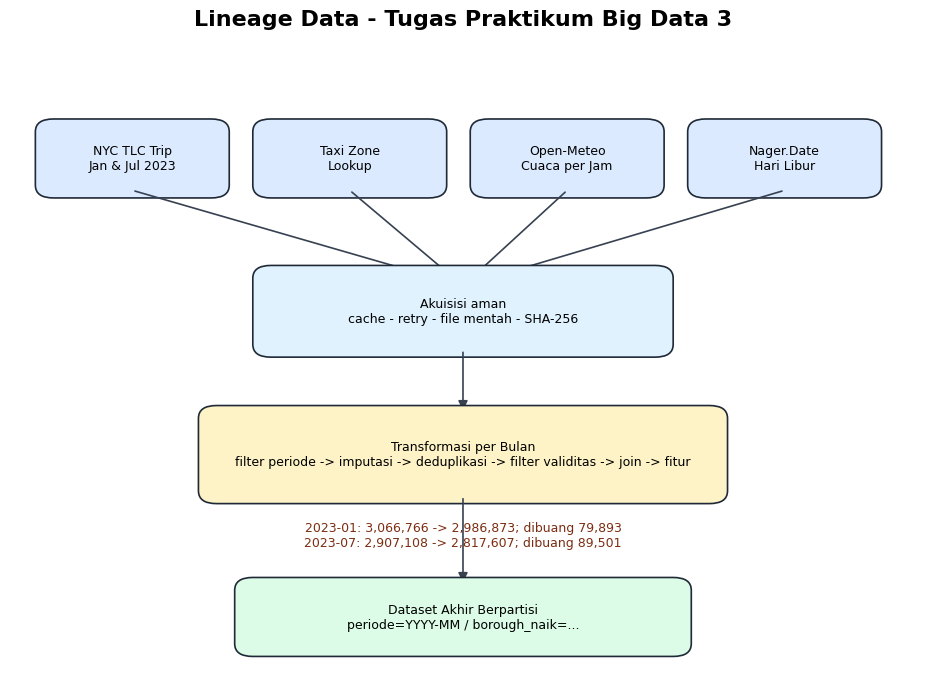

Lineage CSV : /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/lineage.csv
Diagram PNG : /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/diagram_lineage.png
Diagram PDF : /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/diagram_lineage.pdf


In [11]:
# Tambahkan lineage referensi yang sudah dicatat di awal.
lineage_df = pd.DataFrame(lineage_records).drop_duplicates(
    subset=["sumber", "periode", "asal"], keep="last"
)
PATH_LINEAGE = DIR_SIMPAN / "lineage.csv"
lineage_df.to_csv(PATH_LINEAGE, index=False)

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def kotak(ax, x, y, w, h, teks, warna):
    bentuk = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#1f2937",
        facecolor=warna,
    )
    ax.add_patch(bentuk)
    ax.text(
        x + w / 2, y + h / 2, teks,
        ha="center", va="center", fontsize=9,
        wrap=True,
    )


def panah(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=14,
        linewidth=1.2, color="#374151",
    ))


fig, ax = plt.subplots(figsize=(11.69, 8.27))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title(
    "Lineage Data - Tugas Praktikum Big Data 3",
    fontsize=16, fontweight="bold", pad=18,
)

sumber = [
    (0.04, "NYC TLC Trip\nJan & Jul 2023"),
    (0.28, "Taxi Zone\nLookup"),
    (0.52, "Open-Meteo\nCuaca per Jam"),
    (0.76, "Nager.Date\nHari Libur"),
]
for x, teks in sumber:
    kotak(ax, x, 0.78, 0.19, 0.10, teks, "#dbeafe")
    panah(ax, x + 0.095, 0.78, 0.50, 0.63)

kotak(
    ax, 0.28, 0.53, 0.44, 0.12,
    "Akuisisi aman\ncache - retry - file mentah - SHA-256",
    "#e0f2fe",
)
panah(ax, 0.50, 0.53, 0.50, 0.43)

transformasi = (
    "Transformasi per Bulan\n"
    "filter periode -> imputasi -> deduplikasi -> "
    "filter validitas -> join -> fitur"
)
kotak(ax, 0.22, 0.30, 0.56, 0.13, transformasi, "#fef3c7")

ringkas_buang = []
for bulan in PERIODE:
    meta = metadata_bulan[bulan]
    ringkas_buang.append(
        f"{bulan}: {meta['baris_awal']:,} -> "
        f"{meta['baris_akhir']:,}; dibuang "
        f"{meta['baris_awal'] - meta['baris_akhir']:,}"
    )
ax.text(
    0.50, 0.26, "\n".join(ringkas_buang),
    ha="center", va="top", fontsize=9, color="#7c2d12",
)

panah(ax, 0.50, 0.30, 0.50, 0.16)
kotak(
    ax, 0.26, 0.06, 0.48, 0.10,
    "Dataset Akhir Berpartisi\nperiode=YYYY-MM / borough_naik=...",
    "#dcfce7",
)

PATH_DIAGRAM_PNG = DIR_SIMPAN / "diagram_lineage.png"
PATH_DIAGRAM_PDF = DIR_SIMPAN / "diagram_lineage.pdf"
plt.savefig(PATH_DIAGRAM_PNG, dpi=200, bbox_inches="tight")
plt.savefig(PATH_DIAGRAM_PDF, bbox_inches="tight")
plt.show()

print("Lineage CSV :", PATH_LINEAGE)
print("Diagram PNG :", PATH_DIAGRAM_PNG)
print("Diagram PDF :", PATH_DIAGRAM_PDF)

**Penjelasan kode.** Diagram dibentuk dari metadata hasil eksekusi sehingga jumlah baris awal, akhir, dan yang dibuang bukan angka contoh. Panah memperlihatkan aliran sumber menuju proses akuisisi, transformasi, dan dataset akhir.

## R.11 Uji Idempotensi dan Reproducibility

Pipeline dijalankan kembali untuk dua bulan. Sebelum dan sesudah pemanggilan kedua, nama, ukuran, dan waktu modifikasi berkas dibandingkan. Jika sama, panggilan kedua tidak menghasilkan berkas baru dan tidak menulis ulang data lama.

In [12]:
def snapshot_berkas(direktori):
    return {
        str(path.relative_to(direktori)): (
            path.stat().st_size,
            path.stat().st_mtime_ns,
        )
        for path in Path(direktori).rglob("*")
        if path.is_file()
    }


sebelum = snapshot_berkas(DIR_OUTPUT)
hasil_kedua = [pipeline_bulan(bulan) for bulan in PERIODE]
sesudah = snapshot_berkas(DIR_OUTPUT)

tidak_berubah = sebelum == sesudah
semua_cache = all(
    item["status"] == "cache" for item in hasil_kedua
)

print("Status pemanggilan kedua:", [
    item["status"] for item in hasil_kedua
])
print("Jumlah berkas sebelum:", len(sebelum))
print("Jumlah berkas sesudah:", len(sesudah))
print("Idempoten:", tidak_berubah and semua_cache)

assert tidak_berubah and semua_cache

[2023-01] cache keluaran ditemukan; proses dilewati
[2023-07] cache keluaran ditemukan; proses dilewati
Status pemanggilan kedua: ['cache', 'cache']
Jumlah berkas sebelum: 18
Jumlah berkas sesudah: 18
Idempoten: True


**Pembahasan.** Status `cache`, jumlah berkas yang tetap, serta hasil `Idempoten: True` menunjukkan input dan parameter yang sama tidak mengubah keluaran yang sudah lengkap. Untuk memenuhi pemeriksaan modul sepenuhnya, jalankan notebook ini melalui **Restart session and run all** pada runtime Colab yang bersih dan simpan seluruh outputnya.

## R.12 Menyimpan Artefak Akhir dan Arsip ZIP

Sel terakhir menyimpan catatan kinerja, memperbarui lineage setelah uji idempotensi, dan membuat `trips_bersih.zip`. Parquet sudah terkompresi sehingga pembuatan ZIP dapat memerlukan waktu tanpa banyak mengurangi ukuran.

In [13]:
pd.DataFrame(catatan_kinerja).to_csv(
    DIR_ARTEFAK / "pengukuran_kinerja.csv", index=False
)

lineage_df = pd.DataFrame(lineage_records).drop_duplicates(
    subset=["sumber", "periode", "asal"], keep="last"
)
lineage_df.to_csv(PATH_LINEAGE, index=False)

path_zip = DIR_SIMPAN / "trips_bersih.zip"
# Buat ZIP sementara pada filesystem Google Drive yang sama dengan
# berkas tujuan agar os.replace() tidak memicu Invalid cross-device link.
base_sementara = DIR_SIMPAN / "trips_bersih_sementara"
zip_sementara = Path(str(base_sementara) + ".zip")
if zip_sementara.exists():
    zip_sementara.unlink()

shutil.make_archive(
    str(base_sementara),
    "zip",
    root_dir=DIR_OUTPUT,
)
os.replace(zip_sementara, path_zip)

artefak_wajib = {
    "laporan_kualitas.csv": path_laporan_gabungan,
    "lineage.csv": PATH_LINEAGE,
    "kamus_data.md": PATH_KAMUS,
    "trips_bersih.zip": path_zip,
    "diagram_lineage.png": PATH_DIAGRAM_PNG,
    "diagram_lineage.pdf": PATH_DIAGRAM_PDF,
}

audit_artefak = pd.DataFrame([
    {
        "artefak": nama,
        "tersedia": path.exists(),
        "ukuran_mb": round(path.stat().st_size / 1024**2, 4)
        if path.exists() else np.nan,
        "lokasi": str(path),
    }
    for nama, path in artefak_wajib.items()
])
display(audit_artefak)

if not audit_artefak["tersedia"].all():
    raise FileNotFoundError("Masih ada artefak wajib yang belum dibuat")

print("Artefak pipeline selesai dibuat.")
print("Laporan PDF utama disusun terpisah berdasarkan output notebook.")

,artefak,tersedia,ukuran_mb,lokasi
0,laporan_kualitas.csv,True,0.0009,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
1,lineage.csv,True,0.0012,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
2,kamus_data.md,True,0.0042,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
3,trips_bersih.zip,True,152.9397,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
4,diagram_lineage.png,True,0.1509,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
5,diagram_lineage.pdf,True,0.0268,/content/drive/MyDrive/BigData/Praktikum3/Tuga...


Artefak pipeline selesai dibuat.
Laporan PDF utama disusun terpisah berdasarkan output notebook.


## R.13 Ringkasan Hasil Aktual

Ringkasan berikut mengambil angka langsung dari hasil pipeline. Teks ini dapat dijadikan dasar pembahasan laporan, tetapi dugaan penyebab tetap perlu dibedakan dari fakta hasil pengukuran.

In [15]:
terbesar = komparatif.iloc[0]

print("RINGKASAN")
for bulan in PERIODE:
    meta = metadata_bulan[bulan]
    persen = meta["baris_akhir"] / meta["baris_awal"] * 100
    print(
        f"- {bulan}: {meta['baris_akhir']:,} dari "
        f"{meta['baris_awal']:,} baris dipertahankan "
        f"({persen:.4f}%)."
    )

print(f"- Duplikat antar-bulan: {duplikat_antar_bulan:,} baris.")
print(
    f"- Perubahan kualitas terbesar: {terbesar['aturan']} "
    f"sebesar {terbesar['selisih_poin_persen']:+.4f} "
    "poin persentase."
)
for _, baris in cakupan_libur.iterrows():
    print(
        f"- {baris['periode']}: "
        f"{baris['perjalanan_hari_libur']:,} perjalanan "
        "mendapat penanda hari libur nasional."
    )

RINGKASAN
- 2023-01: 2,986,873 dari 3,066,766 baris dipertahankan (97.3949%).
- 2023-07: 2,817,607 dari 2,907,108 baris dipertahankan (96.9213%).
- Duplikat antar-bulan: 0 baris.
- Perubahan kualitas terbesar: kelengkapan: passenger_count ada sebesar +0.5874 poin persentase.
- 2023-01: 141,392 perjalanan mendapat penanda hari libur nasional.
- 2023-07: 55,819 perjalanan mendapat penanda hari libur nasional.


# Referensi Sumber Data

1. NYC Taxi & Limousine Commission, TLC Trip Record Data: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
2. Open-Meteo, Historical Weather API: https://open-meteo.com/en/docs/historical-weather-api
3. Nager Holidays, Holiday API: https://nagerholidays.com/api
4. pandas Documentation, Merge, join, concatenate and compare: https://pandas.pydata.org/docs/user_guide/merging.html

